# 🎵 Analisis Sentimen Google Play Store — Aplikasi Spotify

Proyek ini menganalisis sentimen ulasan pengguna aplikasi **Spotify** di Google Play Store.
Klasifikasi **Binary**: Negatif vs Positif (rating 3/netral dibuang).

## Tiga Skema Pelatihan
| Skema | Algoritma | Fitur | Split |
|-------|-----------|-------|-------|
| 1 | LinearSVC + regularisasi kuat | TF-IDF (1,3)-gram + char | 80/20 |
| 2 | Bi-LSTM + Dropout agresif | Embedding | 80/20 |
| 3 | Random Forest + SMOTE | Word2Vec | 70/30 |


In [ ]:
!pip install -q google-play-scraper sastrawi gensim nltk scikit-learn tensorflow wordcloud matplotlib seaborn imbalanced-learn
print('Instalasi selesai')

In [2]:
import re, warnings, pickle, time

# Specific warning suppression instead of global ignore (lebih aman saat debugging)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import pandas as pd
SEED = 42
np.random.seed(SEED)

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

from gensim.models import Word2Vec

import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

print(f'Import selesai | TF: {tf.__version__}')


Import selesai | TF: 2.19.0


# 🔍 Scraping Data Spotify Play Store

Menggunakan `filter_score_with` untuk scraping stratified per rating.
Rating 3 (netral) **dibuang** — hanya rating 1–2 (negatif) dan 4–5 (positif) yang digunakan.


In [3]:
# Atau load dari file jika sudah ada
df = pd.read_csv('/content/ulasan_sp.csv')

print(f'Total data  : {len(df):,}')
print(f'Kolom       : {df.columns.tolist()}')
print('\nDistribusi rating:')
print(df['score'].value_counts().sort_index())

Total data  : 17,000
Kolom       : ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

Distribusi rating:
score
1    5304
2    1991
3    2186
4    2105
5    5414
Name: count, dtype: int64


/tmp/ipykernel_2464/1133989350.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1','2','3','4','5'], fontsize=12)


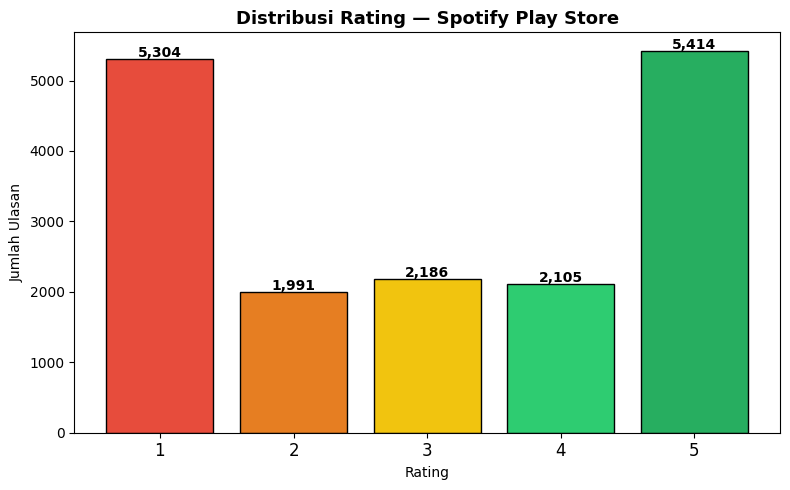

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
rc = df['score'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = ax.bar(rc.index.astype(str), rc.values, color=colors, edgecolor='black')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2., b.get_height()+30,
            f'{int(b.get_height()):,}', ha='center', fontweight='bold')
ax.set_title('Distribusi Rating — Spotify Play Store',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Jumlah Ulasan')
ax.set_xticklabels(['1','2','3','4','5'], fontsize=12)
plt.tight_layout()
plt.savefig('distribusi_rating_spotify.png', dpi=150, bbox_inches='tight')
plt.show()

# 🏷️ Pelabelan Sentimen (Binary)
| Rating | Label |
|--------|-------|
| 1–2 ⭐ | negatif (0) |
| 3 ⭐   | **dibuang** |
| 4–5 ⭐ | positif (1) |


In [5]:
df = df[['score','content']].copy()
df.columns = ['score','text']
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != ''].reset_index(drop=True)

# Binary classification: buang rating 3 (netral)
df = df[df['score'] != 3].reset_index(drop=True)

label_map  = {'negatif': 0, 'positif': 1}
label_imap = {0: 'negatif', 1: 'positif'}

df['label']     = df['score'].apply(lambda r: 'negatif' if r <= 2 else 'positif')
df['label_enc'] = df['label'].map(label_map)

print('Distribusi label (sebelum balancing):')
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    print(f'  {lbl:10s}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print(f'  Total     : {len(df):,}')


Distribusi label (sebelum balancing):
  positif   : 7,519 (50.8%)
  negatif   : 7,295 (49.2%)
  Total     : 14,814


# ⚖️ Balancing Kelas (Binary)

Samakan jumlah data negatif dan positif agar model tidak bias ke kelas mayoritas.


In [6]:
df_neg = df[df['label'] == 'negatif']
df_pos = df[df['label'] == 'positif']

# Samakan ke ukuran kelas terkecil
n_min = min(len(df_neg), len(df_pos))
n_min = max(n_min, 3500)  # minimal 3.500 per kelas

def balance_cls(df_cls, n):
    if len(df_cls) >= n:
        return resample(df_cls, replace=False, n_samples=n, random_state=SEED)
    return resample(df_cls, replace=True, n_samples=n, random_state=SEED)

df = pd.concat([
    balance_cls(df_neg, n_min),
    balance_cls(df_pos, n_min),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Distribusi setelah balancing (masing-masing {n_min:,}):')
print(df['label'].value_counts())
print(f'Total: {len(df):,}')


Distribusi setelah balancing (masing-masing 7,295):
label
negatif    7295
positif    7295
Name: count, dtype: int64
Total: 14,590


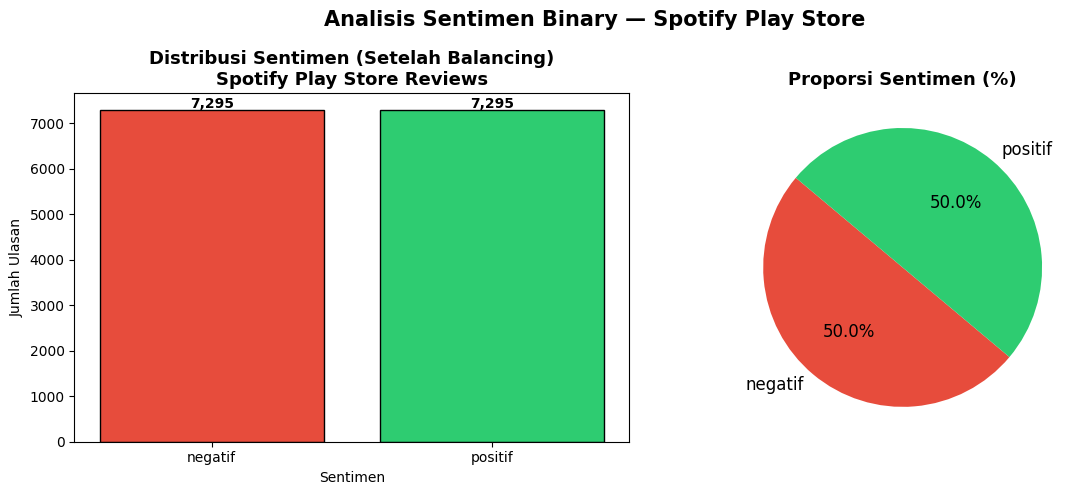

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
lc = df['label'].value_counts()
cl = ['#e74c3c', '#2ecc71']  # merah=negatif, hijau=positif

axes[0].bar(lc.index, lc.values, color=cl, edgecolor='black')
axes[0].set_title('Distribusi Sentimen (Setelah Balancing)\nSpotify Play Store Reviews',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentimen'); axes[0].set_ylabel('Jumlah Ulasan')
for i_b, v in enumerate(lc.values):
    axes[0].text(i_b, v+30, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(lc.values, labels=lc.index, autopct='%1.1f%%',
            colors=cl, startangle=140, textprops={'fontsize':12})
axes[1].set_title('Proporsi Sentimen (%)', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Sentimen Binary — Spotify Play Store', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_sentimen_spotify.png', dpi=150, bbox_inches='tight')
plt.show()


# 🧹 Preprocessing — Tanpa Stemming

Stemming Sastrawi merusak kata sentimen penting dan menyebabkan overfitting karena fitur jadi terlalu umum. Review Play Store yang pendek justru lebih baik tanpa stemming.

In [8]:
slang_dict = {
    # Negasi sangat penting
    'gak':'tidak','ga':'tidak','ngga':'tidak','nggak':'tidak',
    'gk':'tidak','tdk':'tidak','ga':'tidak','kagak':'tidak',
    'bkn':'bukan','jgn':'jangan','gbs':'tidak bisa',
    'tapi':'tapi', # Ensure 'tapi' is not mistakenly normalized if already good
    # Umum
    'tp':'tapi','udh':'sudah','udah':'sudah','blm':'belum',
    'krn':'karena','karna':'karena','jg':'juga','lg':'lagi',
    'yg':'yang','dr':'dari','dgn':'dengan','utk':'untuk',
    'bgt':'banget','bngt':'banget','banget':'sangat',
    'gw':'saya','gue':'saya','emg':'memang','emang':'memang',
    'ok':'baik','oke':'baik','sip':'baik',
    'hrs':'harus','bs':'bisa','msh':'masih','skrg':'sekarang',
    'bbrp':'beberapa','bnyk':'banyak','dikit':'sedikit',
    'bgmn':'bagaimana','knp':'kenapa','dlm':'dalam','luar':'luar',
    'bikin':'membuat','bisa':'bisa','kalo':'kalau','kl':'kalau',
    # Konteks aplikasi
    'app':'aplikasi','apk':'aplikasi','apps':'aplikasi',
    'update':'pembaruan','bug':'error','crash':'mogok',
    'loading':'memuat','buffering':'memuat','lemot':'lambat',
    'lelet':'lambat','ngelag':'lambat','lag':'lambat',
    'notif':'notifikasi','hp':'ponsel','hape':'ponsel',
    'batre':'baterai','batere':'baterai',
    'iklan':'iklan','ads':'iklan',
    'keren':'bagus','mantap':'bagus','mantul':'bagus',
    'jelek':'buruk','parah':'buruk','sampah':'sangat buruk',
    'worth':'sepadan','fix':'perbaiki','tolong':'mohon',
    'ribet':'sulit','susah':'sulit','gampang':'mudah',
    'canggih':'modern','ketinggalan':'ketinggalan zaman',
    # Konteks Spotify
    'lagu':'lagu','musik':'musik','song':'lagu','playlist':'daftar putar',
    'premium':'berbayar','free':'gratis','offline':'tanpa internet',
    'shuffle':'acak','repeat':'ulang','download':'unduh',
    'skip':'lewati','lirik':'lirik','podcast':'podcast',
    'rekomendasi':'rekomendasi','recommend':'rekomendasi',
    'langganan':'berlangganan','subscribe':'berlangganan',
    'mahal':'mahal','murah':'murah','gratis':'gratis',
    'berbayar':'berbayar','gratisan':'gratis'
}

def normalize_slang(text):
    # Menangani negasi multi-kata
    negations = {
        'tidak sesuai': 'kecewa',
        'kurang sesuai': 'kecewa',
        'tidak bagus': 'buruk',
        'tidak baik': 'buruk',
        'kurang memuaskan': 'kecewa',
        'tidak bisa': 'gagal',
        'tidak berfungsi': 'rusak',
        'tidak ada': 'kosong',
        'bukan masalah': 'baik',
        'tidak sesuai ekspektasi': 'sangat kecewa' # Menambahkan negasi negatif
    }
    for k, v in negations.items():
        text = text.replace(k, v)
    return ' '.join([slang_dict.get(w, w) for w in text.split()])

print(f'Kamus slang: {len(slang_dict)} entri')

Kamus slang: 103 entri


In [9]:
!pip install Sastrawi # Ensure Sastrawi is installed

import nltk
nltk.download('stopwords', quiet=True) # Download stopwords to fix LookupError

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.corpus import stopwords # Added this import

sw_factory    = StopWordRemoverFactory()
all_sw        = set(sw_factory.get_stop_words()) | set(stopwords.words('english'))

# Kata sentimen penting — jangan hapus
keep = {
    'tidak','bukan','belum','jangan','tanpa','tak',
    'kurang','buruk','bagus','baik','jelek','parah',
    'lambat','cepat','panas','boros','hemat',
    'crash','error','mogok','lemot','lelet',
    'kecewa','puas','suka','benci','senang','sedih',
    'mahal','murah','gratis','berbayar',
    'bagus','keren','mantap','sampah','percuma',
    'menyebalkan','mengecewakan','memuaskan',
    'recommended','direkomendasikan','sepadan',
}
all_sw -= keep

def cleaning_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  # 'bagusss' → 'baguss'
    emoji = re.compile(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0]+', flags=re.UNICODE)
    return re.sub(r'\s+', ' ', emoji.sub('', text)).strip()

def full_preprocessing(text):
    text   = cleaning_text(text).lower()
    text   = normalize_slang(text)
    tokens = word_tokenize(text)

    negation_terms = ['tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'tak', 'kurang']
    processed_tokens = []
    i = 0
    while i < len(tokens):
        token = tokens[i]
        if token in negation_terms and i + 1 < len(tokens):
            processed_tokens.append(token)
            processed_tokens.append(tokens[i+1] + '_NEG') # Mark the next word as negated
            i += 2
        else:
            processed_tokens.append(token)
            i += 1

    tokens = [t for t in processed_tokens if t not in all_sw and len(t) > 1]
    # TANPA stemming — cegah overfitting & jaga kata sentimen
    return ' '.join(tokens)

print('Fungsi preprocessing siap (tanpa stemming, dengan penanganan negasi)')

Fungsi preprocessing siap (tanpa stemming, dengan penanganan negasi)


In [10]:
print('Preprocessing...')
df['text_clean'] = df['text'].apply(full_preprocessing)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Selesai. Total: {len(df):,}')

avg_len = df['text_clean'].apply(lambda x: len(x.split())).mean()
print(f'Rata-rata panjang teks: {avg_len:.1f} kata')
df[['text','text_clean','label']].head(5)

Preprocessing...
Selesai. Total: 14,590
Rata-rata panjang teks: 24.2 kata


,text,text_clean,label
0,"Jangan semuanya dikit-dikit untuk premium, bah...",jangan semuanya_NEG sedikit sedikit berbayar b...,negatif
1,aplikasinya sangat lumayan bagus semoga ajah b...,aplikasinya sangat lumayan bagus semoga ajah l...,positif
2,"kebanyakan iklan, kurangi iklan nya yaaa devel...",kebanyakan iklan kurangi iklan nya yaa develop...,negatif
3,"Dasar Developer Mata Uang! , Aku hanya mau den...",dasar developer mata uang aku mau dengerin lag...,negatif
4,Spotify perfect bgt!! •Karna bisa dengerin lag...,spotify perfect banget dengerin lagu aplikasi ...,positif


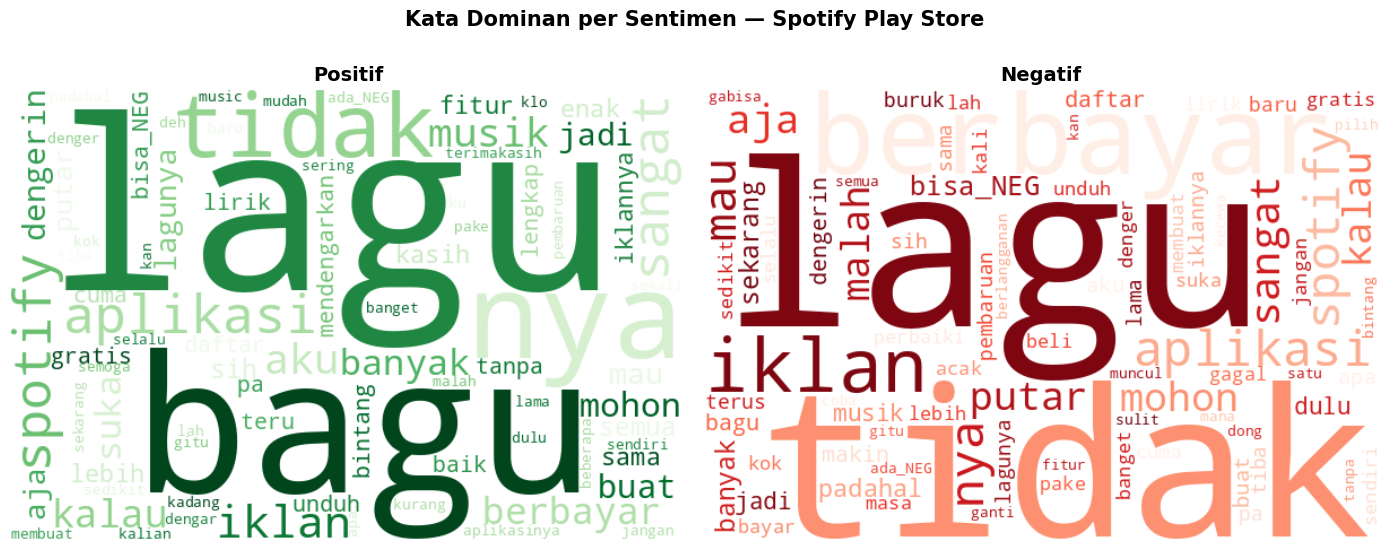

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, (lbl, cmap, title) in zip(axes, [
    ('positif', 'Greens', 'Positif'),
    ('negatif', 'Reds',   'Negatif'),
]):
    txt = ' '.join(df[df['label'] == lbl]['text_clean'])
    wc  = WordCloud(width=600, height=400, background_color='white',
                    colormap=cmap, max_words=80, collocations=False).generate(txt or 'kosong')
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.suptitle('Kata Dominan per Sentimen — Spotify Play Store', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_spotify.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
X = df['text_clean']
y = df['label_enc']
print('Data siap untuk training.')
print(df['label'].value_counts())

Data siap untuk training.
label
negatif    7295
positif    7295
Name: count, dtype: int64


# 🤖 Skema 1: TF-IDF + LinearSVC (80/20)


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

print('='*60)
print('SKEMA 1: TF-IDF + LinearSVC (80/20)')
print('='*60)

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {len(X_train1):,} | Test: {len(X_test1):,}')

tfidf1 = TfidfVectorizer(
    ngram_range   = (1, 3),       # kata dan frasa 1-3 kata
    max_features  = 150000,       # lebih banyak fitur (saran: naikkan dari 100k)
    sublinear_tf  = True,
    min_df        = 2,
    max_df        = 0.90,
    strip_accents = 'unicode',
    analyzer      = 'word',
)

# TF-IDF karakter untuk tangkap negasi dan suffix (fitur tambahan)
tfidf_char = TfidfVectorizer(
    ngram_range   = (3, 6),       # karakter n-gram
    max_features  = 50000,
    sublinear_tf  = True,
    min_df        = 3,
    max_df        = 0.90,
    strip_accents = 'unicode',
    analyzer      = 'char_wb',   # char within word boundary
)

import scipy.sparse as sp
X_tr1_word = tfidf1.fit_transform(X_train1)
X_te1_word = tfidf1.transform(X_test1)
X_tr1_char = tfidf_char.fit_transform(X_train1)
X_te1_char = tfidf_char.transform(X_test1)

# Gabungkan fitur kata + karakter
X_tr1 = sp.hstack([X_tr1_word, X_tr1_char])
X_te1 = sp.hstack([X_te1_word, X_te1_char])
print(f'TF-IDF gabungan shape: {X_tr1.shape}')

# GridSearchCV untuk hyperparameter tuning LinearSVC (SARAN 1)
param_grid = {'C': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 2.0, 5.0, 10.0]}
clf_base = LinearSVC(max_iter=5000, random_state=SEED, dual=False)
grid_search = GridSearchCV(
    clf_base, param_grid, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_tr1, y_train1)

best_c = grid_search.best_params_['C']
best_cv_acc = grid_search.best_score_
print(f'\nBest C: {best_c} | Best CV Accuracy: {best_cv_acc*100:.2f}%')

# Train final model dengan C terbaik
svm_model = LinearSVC(C=best_c, max_iter=5000, random_state=SEED, dual=False)
svm_model.fit(X_tr1, y_train1)

acc_train1 = accuracy_score(y_train1, svm_model.predict(X_tr1))
acc_test1  = accuracy_score(y_test1,  svm_model.predict(X_te1))

print(f'\nAkurasi Training : {acc_train1*100:.2f}%')
print(f'Akurasi Testing  : {acc_test1*100:.2f}%')
gap = (acc_train1 - acc_test1) * 100
print(f'Gap Train-Test   : {gap:.2f}% {"(overfitting ringan)" if gap > 10 else "(baik)"}')
print(f'Status Akurasi   : {"LULUS >92%" if acc_test1>=0.92 else "Belum 92%"}')
print('\nClassification Report:')
print(classification_report(y_test1, svm_model.predict(X_te1),
      target_names=['negatif','positif']))


SKEMA 1: TF-IDF + LinearSVC (80/20)
Train: 11,672 | Test: 2,918
TF-IDF gabungan shape: (11672, 88674)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best C: 0.1 | Best CV Accuracy: 86.71%

Akurasi Training : 93.19%
Akurasi Testing  : 86.74%
Gap Train-Test   : 6.45% (baik)
Status Akurasi   : Belum 92%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.84      0.90      0.87      1459
     positif       0.89      0.83      0.86      1459

    accuracy                           0.87      2918
   macro avg       0.87      0.87      0.87      2918
weighted avg       0.87      0.87      0.87      2918



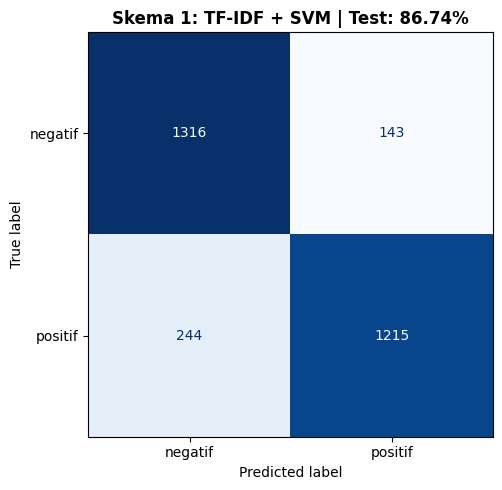

In [14]:
cm1 = confusion_matrix(y_test1, svm_model.predict(X_te1))
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm1, display_labels=['negatif','positif']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Skema 1: TF-IDF + SVM | Test: {acc_test1*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_skema1.png', dpi=150, bbox_inches='tight')
plt.show()


# 🧠 Skema 2: Bi-LSTM Deep Learning (80/20)

In [15]:
print('='*60)
print('SKEMA 2: Bi-LSTM Deep Learning (80/20)')
print('='*60)

VOCAB_SIZE = 20000
MAX_LEN    = 100
EMBED_DIM  = 128
BATCH      = 64
EPOCHS     = 10
NC         = 2   # Binary: negatif / positif

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

keras_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train2)

X_tr2 = pad_sequences(keras_tok.texts_to_sequences(X_train2),
                       maxlen=MAX_LEN, padding='post', truncating='post')
X_te2 = pad_sequences(keras_tok.texts_to_sequences(X_test2),
                       maxlen=MAX_LEN, padding='post', truncating='post')
y_tr2 = to_categorical(y_train2, NC)
y_te2 = to_categorical(y_test2,  NC)
print(f'X_train: {X_tr2.shape} | X_test: {X_te2.shape}')
print(f'Kelas: {NC} (binary: negatif=0, positif=1)')


SKEMA 2: Bi-LSTM Deep Learning (80/20)
X_train: (11672, 100) | X_test: (2918, 100)
Kelas: 2 (binary: negatif=0, positif=1)


In [16]:
from tensorflow.keras.layers import Input, SpatialDropout1D, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.models import Sequential

# Optimasi: Hapus recurrent_dropout & run_eagerly
bilstm = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM),
    SpatialDropout1D(0.4),
    # Hapus recurrent_dropout agar bisa pakai cuDNN (Sangat Penting!)
    Bidirectional(LSTM(48, return_sequences=True, dropout=0.4)),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(24, dropout=0.4)),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.4),
    Dense(NC, activation='softmax')
])

bilstm.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
    run_eagerly=False # Ubah ke False untuk kecepatan maksimal
)

In [17]:
# EarlyStopping dengan patience lebih panjang agar model tidak berhenti terlalu cepat
callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=3,        # Tunggu lebih lama
        restore_best_weights=True, mode='max',
        min_delta=0.001                              # Minimal improvement 0.1%
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,            # Turunkan LR lebih agresif
        patience=4, min_lr=1e-6, verbose=1
    )
]

_ = bilstm(X_tr2[:1])

history2 = bilstm.fit(
    X_tr2, y_tr2,
    epochs=10,
    batch_size=BATCH,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 84s 475ms/step - accuracy: 0.6442 - loss: 1.0497 - val_accuracy: 0.8355 - val_loss: 0.9597 - learning_rate: 0.0010
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 63s 351ms/step - accuracy: 0.8327 - loss: 0.6887 - val_accuracy: 0.8527 - val_loss: 0.5949 - learning_rate: 0.0010
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 59s 379ms/step - accuracy: 0.8747 - loss: 0.5230 - val_accuracy: 0.8578 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 55s 350ms/step - accuracy: 0.8942 - loss: 0.4178 - val_accuracy: 0.8492 - val_loss: 0.4760 - learning_rate: 0.0010
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 83s 360ms/step - accuracy: 0.9127 - loss: 0.3307 - val_accuracy: 0.8475 - val_loss: 0.4648 - learning_rate: 0.0010
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 55s 350ms/step - accuracy: 0.9311 - loss: 0.2647 - val_accuracy: 0.8332 - val_loss: 0.4840 - learning_rate: 0.0010


In [18]:
_ , acc_train2 = bilstm.evaluate(X_tr2, y_tr2, verbose=0)
_ , acc_test2  = bilstm.evaluate(X_te2, y_te2, verbose=0)
y_pred2       = np.argmax(bilstm.predict(X_te2), axis=1)

print(f'Akurasi Training : {acc_train2*100:.2f}%')
print(f'Akurasi Testing  : {acc_test2*100:.2f}%')
gap = (acc_train2 - acc_test2) * 100
print(f'Gap Train-Test   : {gap:.2f}% {"(overfitting ringan)" if gap > 10 else "(baik)"}')
print(f'Status           : {"LULUS" if acc_test2>=0.85 else "Belum 85%"}')
print(classification_report(y_test2, y_pred2, target_names=['negatif','positif']))


92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step
Akurasi Training : 91.15%
Akurasi Testing  : 86.05%
Gap Train-Test   : 5.10% (baik)
Status           : LULUS
              precision    recall  f1-score   support

     negatif       0.84      0.89      0.86      1459
     positif       0.88      0.83      0.86      1459

    accuracy                           0.86      2918
   macro avg       0.86      0.86      0.86      2918
weighted avg       0.86      0.86      0.86      2918



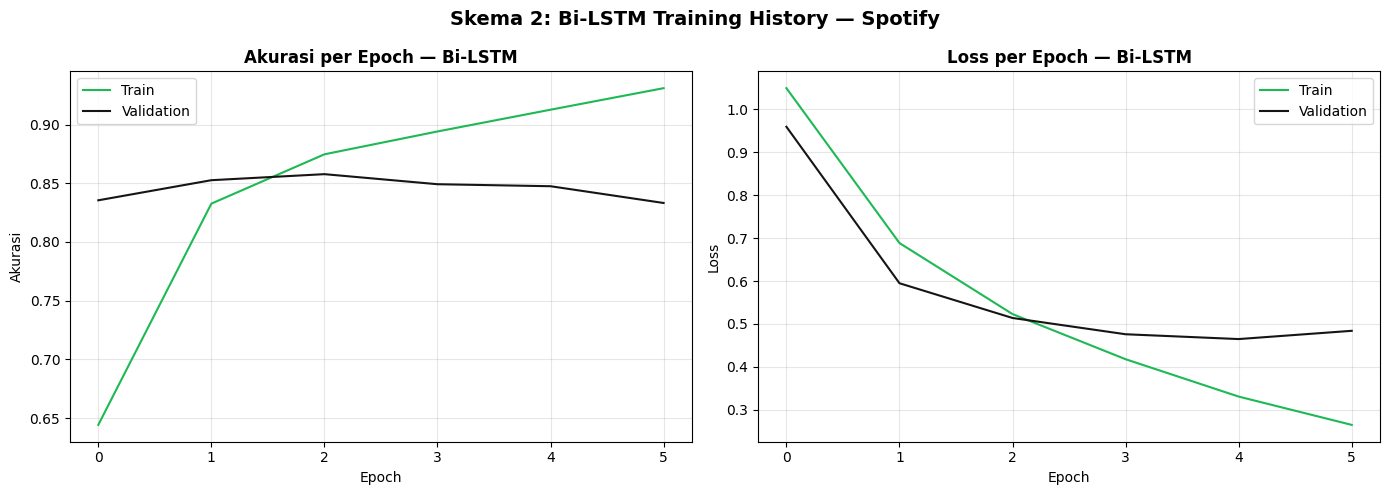

In [19]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, m, t in zip(axes,['accuracy','loss'],['Akurasi','Loss']):
    ax.plot(history2.history[m],          label='Train',      color='#1DB954')  # Spotify green
    ax.plot(history2.history[f'val_{m}'], label='Validation', color='#191414')  # Spotify black
    ax.set_title(f'{t} per Epoch — Bi-LSTM', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(t)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Skema 2: Bi-LSTM Training History — Spotify', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('history_skema2.png', dpi=150, bbox_inches='tight')
plt.show()

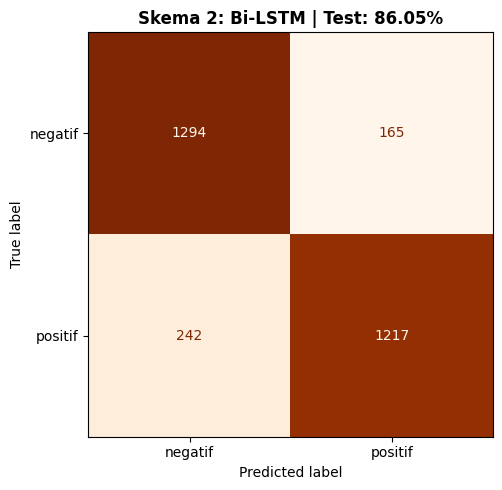

In [20]:
cm2 = confusion_matrix(y_test2, y_pred2)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm2, display_labels=['negatif','positif']).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Skema 2: Bi-LSTM | Test: {acc_test2*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_skema2.png', dpi=150, bbox_inches='tight')
plt.show()


# 🌲 Skema 3: Word2Vec + Random Forest (70/30)

In [21]:
print('='*60)
print('SKEMA 3: Word2Vec + Random Forest (70/30)')
print('='*60)

sents = [t.split() for t in df['text_clean']]
w2v   = Word2Vec(
    sentences=sents, vector_size=200, window=5,
    min_count=2, sg=1, epochs=20, seed=SEED, workers=4
)
print(f'Word2Vec vocab: {len(w2v.wv):,}')

def avg_vec(text, model, size=200):
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_w2v = np.array([avg_vec(t, w2v) for t in df['text_clean']])
y_w2v = df['label_enc'].values

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_w2v, y_w2v, test_size=0.3, random_state=SEED, stratify=y_w2v)
print(f'Train: {len(X_train3):,} | Test: {len(X_test3):,}')

# SMOTE hanya pada training
smote = SMOTE(random_state=SEED)
X_tr3_sm, y_tr3_sm = smote.fit_resample(X_train3, y_train3)
print(f'Setelah SMOTE: {len(X_tr3_sm):,}')

rf = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 20,
    min_samples_leaf  = 5,
    min_samples_split = 10,
    max_features      = 'sqrt',
    random_state      = SEED,
    n_jobs            = -1,
    class_weight      = 'balanced'
)
rf.fit(X_tr3_sm, y_tr3_sm)

acc_train3 = accuracy_score(y_train3, rf.predict(X_train3))
acc_test3  = accuracy_score(y_test3,  rf.predict(X_test3))

print(f'\nAkurasi Training : {acc_train3*100:.2f}%')
print(f'Akurasi Testing  : {acc_test3*100:.2f}%')
gap = (acc_train3 - acc_test3) * 100
print(f'Gap Train-Test   : {gap:.2f}% {"(overfitting ringan)" if gap > 10 else "(baik)"}')
print(f'Status           : {"LULUS" if acc_test3>=0.85 else "Belum 85%"}')
print(classification_report(y_test3, rf.predict(X_test3), target_names=['negatif','positif']))


SKEMA 3: Word2Vec + Random Forest (70/30)
Word2Vec vocab: 7,824
Train: 10,213 | Test: 4,377
Setelah SMOTE: 10,214

Akurasi Training : 97.27%
Akurasi Testing  : 84.67%
Gap Train-Test   : 12.60% (overfitting ringan)
Status           : Belum 85%
              precision    recall  f1-score   support

     negatif       0.82      0.89      0.85      2189
     positif       0.88      0.81      0.84      2188

    accuracy                           0.85      4377
   macro avg       0.85      0.85      0.85      4377
weighted avg       0.85      0.85      0.85      4377



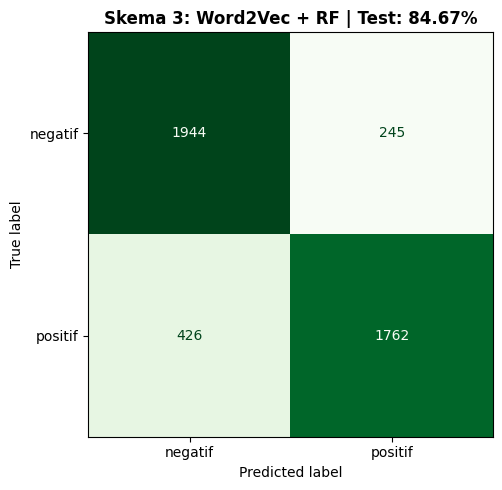

In [22]:
cm3 = confusion_matrix(y_test3, rf.predict(X_test3))
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm3, display_labels=['negatif','positif']).plot(
    ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Skema 3: Word2Vec + RF | Test: {acc_test3*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_skema3.png', dpi=150, bbox_inches='tight')
plt.show()


# 📊 Perbandingan Ketiga Skema

In [23]:
results = pd.DataFrame({
    'Skema'            : ['Skema 1: TF-IDF+SVM','Skema 2: Bi-LSTM','Skema 3: Word2Vec+RF'],
    'Split'            : ['80/20','80/20','70/30'],
    'Train (%)'        : [round(acc_train1*100,2), round(acc_train2*100,2), round(acc_train3*100,2)],
    'Test (%)'         : [round(acc_test1*100,2),  round(acc_test2*100,2),  round(acc_test3*100,2)],
    'Gap (%)'          : [round((acc_train1-acc_test1)*100,2),
                          round((acc_train2-acc_test2)*100,2),
                          round((acc_train3-acc_test3)*100,2)],
    'Status'           : ['Berhasil' if x>=0.85 else 'Gagal' for x in [acc_test1,acc_test2,acc_test3]],
})
print(results.to_string(index=False))

               Skema Split  Train (%)  Test (%)  Gap (%)   Status
 Skema 1: TF-IDF+SVM 80/20      93.19     86.74     6.45 Berhasil
    Skema 2: Bi-LSTM 80/20      91.15     86.05     5.10 Berhasil
Skema 3: Word2Vec+RF 70/30      97.27     84.67    12.60    Gagal


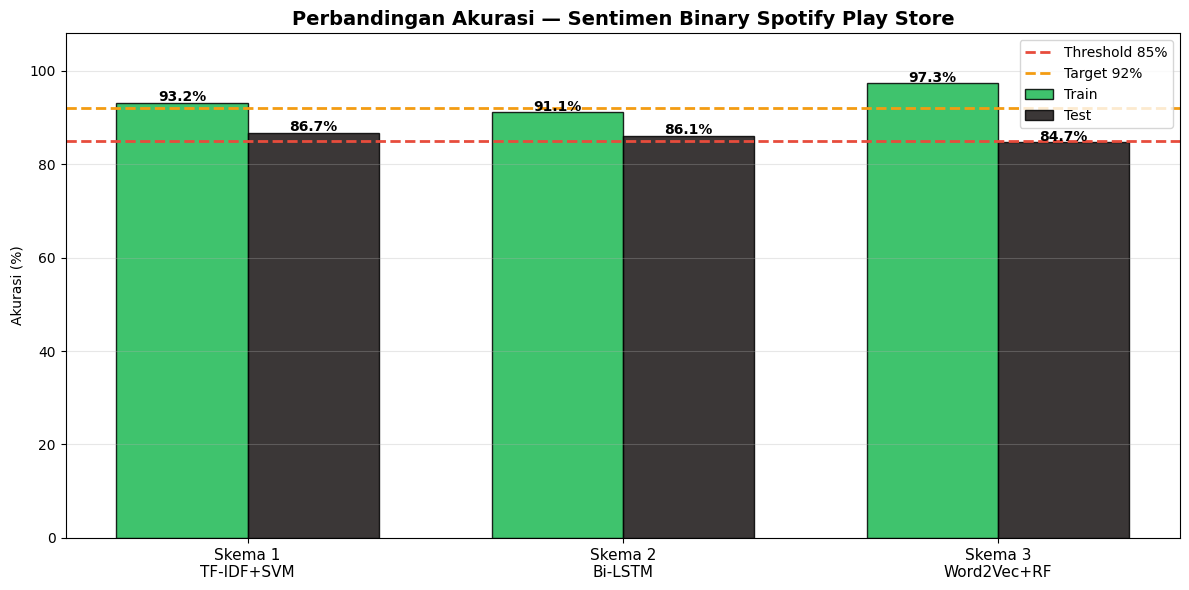

In [24]:
fig, ax = plt.subplots(figsize=(12,6))
x=np.arange(3); w=0.35
b1=ax.bar(x-w/2,[acc_train1*100,acc_train2*100,acc_train3*100],w,
          label='Train',color='#1DB954',alpha=0.85,edgecolor='black')
b2=ax.bar(x+w/2,[acc_test1*100,acc_test2*100,acc_test3*100],w,
          label='Test', color='#191414',alpha=0.85,edgecolor='black')
ax.axhline(85,color='#e74c3c',linestyle='--',linewidth=2,label='Threshold 85%')
ax.axhline(92,color='#f39c12',linestyle='--',linewidth=2,label='Target 92%')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2.,b.get_height()+0.3,
            f'{b.get_height():.1f}%',ha='center',fontsize=10,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Skema 1\nTF-IDF+SVM','Skema 2\nBi-LSTM','Skema 3\nWord2Vec+RF'],fontsize=11)
ax.set_title('Perbandingan Akurasi — Sentimen Binary Spotify Play Store',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Akurasi (%)'); ax.set_ylim(0,108)
ax.legend(); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_skema.png',dpi=150,bbox_inches='tight')
plt.show()


# 🔍 Inference / Testing Model

In [27]:
def predict_bilstm(text):
    c     = full_preprocessing(text)
    p     = pad_sequences(keras_tok.texts_to_sequences([c]), maxlen=MAX_LEN, padding='post')
    proba = bilstm.predict(p, verbose=0)[0]
    return label_imap[np.argmax(proba)], proba

def predict_svm(text):
    c = full_preprocessing(text)
    # Replicate the feature extraction from training
    c_word = tfidf1.transform([c])
    c_char = tfidf_char.transform([c])
    # Combine word and character features
    c_combined = sp.hstack([c_word, c_char])
    return label_imap[svm_model.predict(c_combined)[0]]

# Test reviews binary — hanya positif & negatif
test_reviews = [
    # Positif
    "Spotify aplikasi terbaik untuk musik, rekomendasinya selalu pas!",
    "Fitur offline download sangat membantu saat tidak ada koneksi internet",
    "Kualitas audio premium sangat jernih, worth it banget bayar langganan",
    "Aplikasinya ringan, tidak boros baterai, dan musiknya lengkap banget",
    # Negatif
    "Aplikasi sering crash dan tidak bisa diputar sama sekali, sangat mengecewakan",
    "Iklan terlalu banyak di versi gratis, sangat mengganggu saat mendengarkan lagu",
    "Harga premium mahal banget tapi fiturnya tidak sesuai ekspektasi",
    "Bukan aplikasi yang bagus, sering error dan menguras baterai",
    "Fiturnya kurang lengkap dibanding kompetitor, kurang memuaskan",
]
expected = ['positif','positif','positif','positif','negatif','negatif','negatif','negatif','negatif']

print('='*70)
print('HASIL INFERENSI BINARY — Sentimen Review Spotify Play Store')
print('='*70)
rows = []
correct_bilstm = 0
correct_svm = 0
for i, rev in enumerate(test_reviews):
    ll, proba = predict_bilstm(rev)
    ls        = predict_svm(rev)
    exp       = expected[i]
    bilstm_ok = 'Berhasil' if ll == exp else 'Gagal'
    svm_ok    = 'Berhasil' if ls == exp else 'Gagal'
    if ll == exp: correct_bilstm += 1
    if ls == exp: correct_svm += 1
    rows.append({'Review':rev[:50]+'...','Bi-LSTM':ll,'SVM':ls,'Ekspektasi':exp,'LSTM OK':bilstm_ok,'SVM OK':svm_ok})
    print(f'\n[{i+1}] "{rev[:65]}"')
    print(f'  Preprocessing : {full_preprocessing(rev)[:80]}')
    print(f'  Bi-LSTM : {ll.upper():10s} {bilstm_ok} | Neg:{proba[0]:.2f} Pos:{proba[1]:.2f}')
    print(f'  SVM     : {ls.upper():10s} {svm_ok} | Ekspektasi: {exp.upper()}')

print(f'\n{"="*70}')
print(f'Akurasi Inferensi — Bi-LSTM: {correct_bilstm}/{len(test_reviews)} | SVM: {correct_svm}/{len(test_reviews)}')
print('='*70)
pd.DataFrame(rows)


HASIL INFERENSI BINARY — Sentimen Review Spotify Play Store

[1] "Spotify aplikasi terbaik untuk musik, rekomendasinya selalu pas!"
  Preprocessing : spotify aplikasi terbaik musik rekomendasinya selalu pas
  Bi-LSTM : POSITIF    Berhasil | Neg:0.02 Pos:0.98
  SVM     : POSITIF    Berhasil | Ekspektasi: POSITIF

[2] "Fitur offline download sangat membantu saat tidak ada koneksi int"
  Preprocessing : fitur tanpa internet_NEG unduh sangat membantu kosong koneksi internet
  Bi-LSTM : POSITIF    Berhasil | Neg:0.18 Pos:0.82
  SVM     : POSITIF    Berhasil | Ekspektasi: POSITIF

[3] "Kualitas audio premium sangat jernih, worth it banget bayar langg"
  Preprocessing : kualitas audio berbayar sangat jernih sepadan sangat bayar berlangganan
  Bi-LSTM : POSITIF    Berhasil | Neg:0.05 Pos:0.95
  SVM     : POSITIF    Berhasil | Ekspektasi: POSITIF

[4] "Aplikasinya ringan, tidak boros baterai, dan musiknya lengkap ban"
  Preprocessing : aplikasinya ringan tidak boros_NEG baterai musiknya lengkap

,Review,Bi-LSTM,SVM,Ekspektasi,LSTM OK,SVM OK
0,"Spotify aplikasi terbaik untuk musik, rekomend...",positif,positif,positif,Berhasil,Berhasil
1,Fitur offline download sangat membantu saat ti...,positif,positif,positif,Berhasil,Berhasil
2,"Kualitas audio premium sangat jernih, worth it...",positif,positif,positif,Berhasil,Berhasil
3,"Aplikasinya ringan, tidak boros baterai, dan m...",positif,positif,positif,Berhasil,Berhasil
4,Aplikasi sering crash dan tidak bisa diputar s...,negatif,negatif,negatif,Berhasil,Berhasil
5,"Iklan terlalu banyak di versi gratis, sangat m...",negatif,negatif,negatif,Berhasil,Berhasil
6,Harga premium mahal banget tapi fiturnya tidak...,negatif,negatif,negatif,Berhasil,Berhasil
7,"Bukan aplikasi yang bagus, sering error dan me...",positif,positif,negatif,Gagal,Gagal
8,"Fiturnya kurang lengkap dibanding kompetitor, ...",positif,negatif,negatif,Gagal,Berhasil


In [31]:
print('INFERENSI INTERAKTIF — Ketik review Spotify untuk diprediksi')
print('Ketik "keluar" untuk berhenti.\n')
while True:
    user_input = input('Masukkan review: ').strip()
    if user_input.lower() in ['keluar','exit','quit','']: print('Selesai.'); break
    ll, proba = predict_bilstm(user_input)
    ls        = predict_svm(user_input)
    # Corrected: Only print probabilities for existing classes (Neg, Pos)
    print(f'  Bi-LSTM : {ll.upper()} | Neg:{proba[0]:.3f} Pos:{proba[1]:.3f}')
    print(f'  SVM     : {ls.upper()}\n')

INFERENSI INTERAKTIF — Ketik review Spotify untuk diprediksi
Ketik "keluar" untuk berhenti.

Masukkan review: bagus
  Bi-LSTM : POSITIF | Neg:0.007 Pos:0.993
  SVM     : POSITIF

Masukkan review: jelek
  Bi-LSTM : NEGATIF | Neg:0.793 Pos:0.207
  SVM     : NEGATIF

Masukkan review: keluar
Selesai.


In [32]:
with open('model_svm_tfidf.pkl','wb') as f:
    pickle.dump({'model':svm_model,'tfidf':tfidf1,'label_map':label_imap}, f)
bilstm.save('model_bilstm_spotify.keras')
with open('keras_tokenizer.pkl','wb') as f:
    pickle.dump(keras_tok, f)
w2v.save('model_word2vec_spotify.model')
df[['text','text_clean','score','label','label_enc']].to_csv(
    'dataset_spotify_labeled.csv', index=False, encoding='utf-8-sig')
print(' Semua model dan dataset berhasil disimpan!')

 Semua model dan dataset berhasil disimpan!


In [33]:
!pip freeze > requirements.txt